11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch [1/5] D Loss: 0.5716 G Loss: 1.4304
Epoch [2/5] D Loss: 0.5044 G Loss: 1.8237
Epoch [3/5] D Loss: 0.3497 G Loss: 2.0138
Epoch [4/5] D Loss: 0.2734 G Loss: 2.3336
Epoch [5/5] D Loss: 0.4533 G Loss: 2.1360


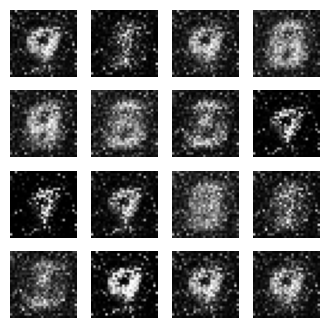

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
(x_train, _), (_, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
batch_size = 64
noise_dim = 100
epochs = 5

x_train[0:0]
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)
dataset
generator = keras.Sequential([
    keras.layers.Input(shape=(noise_dim,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(28 * 28 * 1, activation='tanh'),
    keras.layers.Reshape((28, 28, 1))])

discriminator = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

loss_fn = keras.losses.BinaryCrossentropy()
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002)
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002)

for epoch in range(epochs):

    for real_images in dataset:

        # Find current batch size
        batch_size_now = real_images.shape[0]

        # Create labels
        real_labels = tf.ones((batch_size_now,1))
        fake_labels = tf.zeros((batch_size_now,1))


        # -------- Train Discriminator --------

        noise = tf.random.normal((batch_size_now, noise_dim))

        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape:

            real_output = discriminator(real_images, training=True)

            fake_output = discriminator(fake_images, training=True)

            real_loss = loss_fn(real_labels, real_output)

            fake_loss = loss_fn(fake_labels, fake_output)

            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)

        d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))


        # -------- Train Generator --------

        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:

            generated_images = generator(noise, training=True)

            output = discriminator(generated_images, training=True)

            g_loss = loss_fn(real_labels, output)

        g_gradients = tape.gradient(g_loss, generator.trainable_variables)

        g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))


    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.numpy():.4f} G Loss: {g_loss.numpy():.4f}")


noise = tf.random.normal((16, noise_dim))

generated_images = generator(noise, training=False)

generated_images = (generated_images + 1) / 2

plt.figure(figsize=(4,4))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i,:,:,0], cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
analyze this csv file regarding employee details....the columns specified here are education, joining year, city, payment tier, age, gender, ever benched, experience in current domain, lave or not. role assignment: I want you to act as an employee data analyst and front end content strategist (in short you must help the team leader to give promotion) context: a employee promotion rate analysis report generated from excel sheet which includes,| 1.education background 2.has the employee ever been benched 3.his experience in current domain 4.joining year 5.current salary etc main task: design a professional landing page for presenting the report target audience: team leader HR employee requirements: create a clear landing page structure, it must include title and subtitle add sections for: